# Exercise 04 : Histogram




In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

data = sqlite3.connect('../data/checking-logs.sqlite')

df = pd.read_sql_query("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", data)

data.close()

## Подготовка данных
#### Приведение форматов




In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

df_workdays = df[df['is_weekend'] == False].copy()
df_weekends = df[df['is_weekend'] == True].copy()

df

,timestamp,hour,weekday,is_weekend
0,2020-04-17 05:19:02.744528,5,Friday,False
1,2020-04-17 05:22:35.249331,5,Friday,False
2,2020-04-17 05:22:45.549397,5,Friday,False
3,2020-04-17 05:34:14.691200,5,Friday,False
4,2020-04-17 05:34:24.422370,5,Friday,False
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,20,Thursday,False
3203,2020-05-21 20:22:41.785725,20,Thursday,False
3204,2020-05-21 20:22:41.877806,20,Thursday,False
3205,2020-05-21 20:37:00.129678,20,Thursday,False


#### Таблица для будних дней




In [3]:
workdays_commits = df_workdays.groupby(['weekday', 'hour']).size().reset_index(name='commits')

avg_workdays_hourly = workdays_commits.groupby('hour')['commits'].sum().reset_index()
avg_workdays_hourly

,hour,commits
0,0,6
1,3,2
2,5,15
3,6,3
4,7,31
5,8,37
6,9,30
7,10,132
8,11,88
9,12,79


#### Таблица для выходных дней




In [4]:
weekends_commits = df_weekends.groupby(['weekday', 'hour']).size().reset_index(name='commits')

avg_weekends_hourly = weekends_commits.groupby('hour')['commits'].sum().reset_index()
avg_weekends_hourly

,hour,commits
0,0,6
1,1,6
2,3,1
3,5,2
4,7,16
5,8,28
6,9,22
7,10,28
8,11,118
9,12,57


## Создание финальной таблицы и отрисовка графика




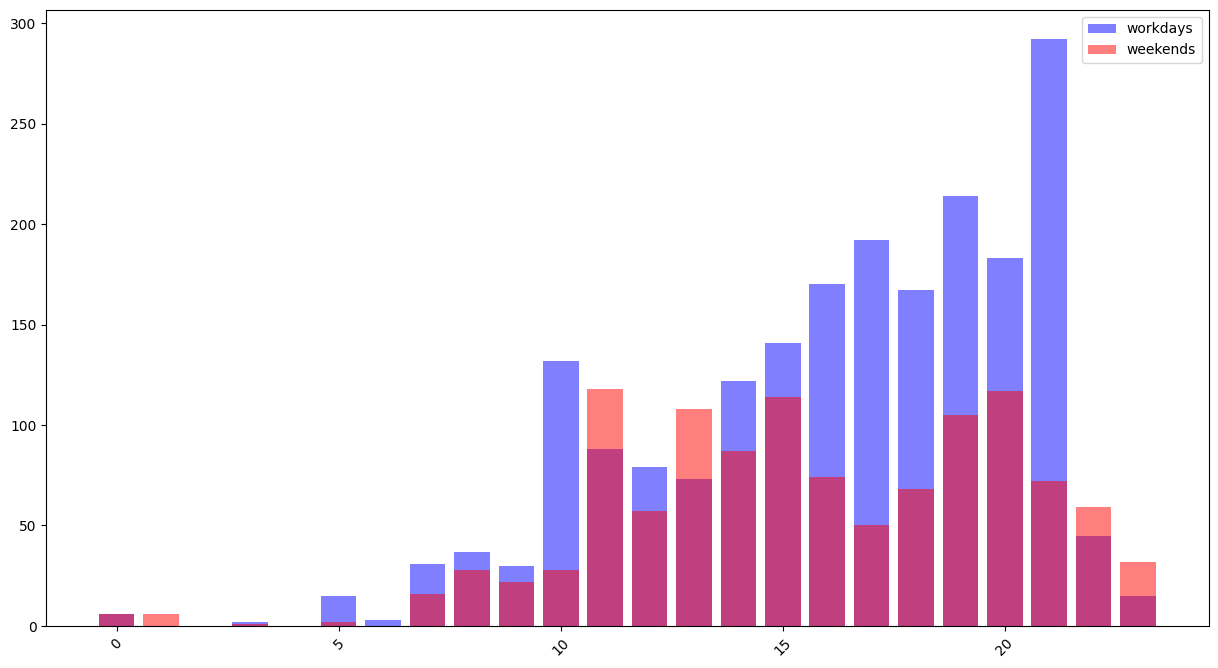

In [5]:
df_avg = avg_workdays_hourly.merge(avg_weekends_hourly, on='hour', how='outer').fillna(0)

all_hours = pd.DataFrame({'hour': range(24)})
df_avg = all_hours.merge(df_avg, on='hour', how='left').fillna(0)

df_avg.set_index('hour', inplace=True)

plt.figure(figsize=(15, 8))
plt.bar(df_avg.index, df_avg.commits_x, alpha=0.5, label='workdays', color='blue')
plt.bar(df_avg.index, df_avg.commits_y, alpha=0.5, label='weekends', color='red')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Are there hours when the total number of commits was higher on weekends than on working days?
#### Yes, for example: 12, 14, 22, 23


